In [1]:
%pip install scikit-learn matplotlib numpy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\mcdon\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Sklearn
This is seen as like the Swiss Army Knife of machine learning, it doesnt handle deep learning like neural networks or ai chat bots but it handles almost eerything else

### Tools
- Classification - Identifying which category an object belongs to (SVM, Random Forest, Logistic Regression)
- Regression - Predicting a continuous-valued attribute like numbers (Linear Regression, Ridge)
- Clustering - Automatic grouping of similar objects (k-Means, Mean-shift)
- Dimensionality Reduction - Reducing the number of random variables to consider (PCA Principal Component Analysis)
- Model Selection - Comparing, validating and choosing parameters (Grid Search, Cross-Validation)
- Preprocessing - Feature extraction and normalisation of data (Min-Max Scaling, One-Hot Encoding)

### Why so popular?
- Once you learn how to use one model in sklearn, you know how to use them all. Every model uses `.fit()` to train and `.predict()` to test workflow

## K-Mean Clusters
K-Means is an unsupervised machine learning algorithm. Unlike classification where you can tell the AI what the categories are, K-Means looks like a pile of unlabeled data and says "Ive noticed these items look similar, so im putting them in a group"

The "K" represents the number of clusters you want. The "Means" refers to the center point of each group.

### Why scaling is important
In K-Means, scaling the data is not just recommended, it is essential.

K-Mean uses Euclidean Distance (the straight line distance betwen points) to decide which cluster a data point belongs to. If one variable has a much larger range than others, it will dominate the distance calculation and blind the model to other features.

#### The Gym Example
Imagine you are clustering Gym members based on
- Weight lifted (Range: 20kg to 200kg)
- Freqency of visits (Range: 1 to 7 times per week)

Without scaling, a difference of 10kg in weight is seen by the algorithm as 10x more important than a difference of 1 visit per week, simply because the numbers are bigger. Scaling both squashes both ranges (usually to between 0 and 1 or -3 + 3) so they carry equal weight

### Mean Squared Error
The MSE is a number that tells you how wrong your models predictions are. Its the standard yardstick for Regression problems where your predicting numbers, like prices or weights. The smaller MSE, the closer your model is to the truth. An MSE of 0 means your model is perfect.

#### How to calculate
- Error: You take the actual value and subtract it by the Predicted value.
- Square the result and that makes all errors positive, so a too high guess doesnt cancel out a too low guess
- Mean: You add up all those squared errors
Average: You divide by the number of data points

### R2 Score
While MSE tells you the magnitude of your error, the R2 Score, also known as the Coefficient of Determination, tells you the quality of your model. It measures how much of the variation in your data is explained by your model, or just how good is the models logic.

Think of R2 as a grade from 0 to 1 or 0% to 100%
- R2 = 100% - Perfect model. Every single prediction is exactly correct
- R2 = 0% - Your model is useless. You would have been just as accurate if you had simply guessed the average value for every single prediction
- R2 < 0 (Negative) - Your model is actually worse than just guessing the average. It means your logic is actively misleading.

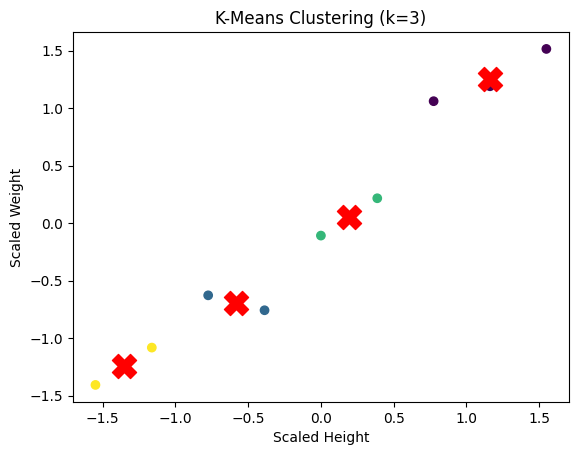

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Create dummy data (e.g., Height vs Weight)
# Imagine these are unlabelled points
X = np.array([[185, 90], [170, 70], [165, 60], [190, 95], [155, 55], 
              [160, 62], [180, 88], [175, 75], [150, 50]])

# 2. Scaling the data (Crucial Step!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Create and fit the K-Means model
# We tell it we want 3 clusters (k=3)
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

# 4. Get the results
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# 5. Visualize the clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X') # Center points
plt.xlabel('Scaled Height')
plt.ylabel('Scaled Weight')
plt.title('K-Means Clustering (k=3)')
plt.show()

## Classification
Sklearn gives you dozens of models, but these four are the workhorses.
- Logistic Regression - Despite the name, its a classifier. It draws a line to seperate two groups (Simple binary choises like yes or no)
- Random Forest - A forest of Decision Trees that vote on the outcome (Complex data with many features)
- SVM (Support Vector Machine) - Finds the widest possible gap between groups (Small datasets with clear boundaries)
- K-Nearest Neighbours (KNN) - Looks at the k closet neighbours and picks the majority lablel (Data where similar things stay together)

In [3]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare Data
# We load a real dataset of flower measurements (cm)
data = load_iris()
X = data.data  # Features: [sepal length, sepal width, petal length, petal width]
y = data.target # Labels: 0 (Setosa), 1 (Versicolour), 2 (Virginica)

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Choose and Train Model
# n_estimators=100 means we are using 100 individual decision trees
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 3. Predict and Score
predictions = clf.predict(X_test)

print(f"--- Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, predictions, target_names=data.target_names))

# --- Bonus: Try a manual prediction ---
# Imagine we found a new flower with these dimensions:
new_flower = [[5.1, 3.5, 1.4, 0.2]]
prediction = clf.predict(new_flower)
flower_name = data.target_names[prediction][0]

print(f"\nManual Test: A flower with 5.1, 3.5, 1.4, 0.2 is predicted to be: {flower_name.upper()}")

--- Model Results ---
Accuracy: 100.00%

Detailed Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Manual Test: A flower with 5.1, 3.5, 1.4, 0.2 is predicted to be: SETOSA


## Linear Regression
Think of Linear Regression as the art of drawing the best fit straight line through a scatter plot of data points. It is a statistical method used to predict the value of one variable based on the value of another.

For example, if you know the square footage of a house, linear regression helps you predict the market price!

The core concept of Linear Regression is when you plot your data, the points usually dont form a perfect line, they are scattered like a cloud, what Linear Regression does is fine the line that minimises the distance between itself and all those scattered points.

- The Independant Variable (X) where it is the variable we already know like the square footage!
- The Dependant Variable (Y) is one where we are trying to predict, like the market price

### How does it work?
In basic algebra, you likely learned the equation of a line as $y = mx + b$. In data science, we write it slightly differently, but the logic remains exactly the same:

$$y = \beta_0 + \beta_1x + \epsilon$$

* **$\beta_0$ (Intercept):** The value of $y$ when $x$ is zero. This is where the line crosses the vertical axis.
* **$\beta_1$ (Slope):** The "coefficient" that tells you how much $y$ is expected to increase (or decrease) for every 1-unit increase in $x$.
* **$\epsilon$ (Error/Residual):** The "noise" or distance between the actual data point and our predicted line. Since real-world data is rarely a perfect line, this accounts for the vertical "miss."

### How do we fine the line of best fit?
We use a method called Ordinary Least Squares (OLS), where we draw a line measuring the vertical distance from every point to that line, then squaring those distances to make them all positive and add them up. The line of best fit is the one where the total sum is the smallest possible number.

### Simple vs Multiple Regression
- Simple Linear Regression - Using one predictor like predicting weight based only on height
- Multiple Linear Regression - Using two or more predictors like predicting weight based on height, age and dailt calorie intake

Intercept (β0): -21.14
Slope (β1): 0.22
Predicted price for 2200 sq ft: $633.71k


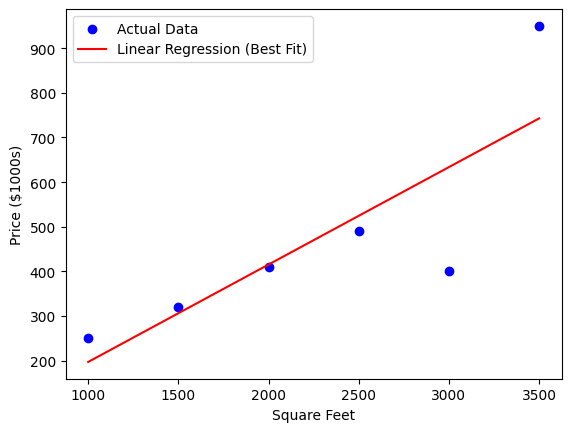

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Prepare some sample data
# x = House Size (Square Feet), y = House Price (in $1000s)
x = np.array([1000, 1500, 2000, 2500, 3000, 3500]).reshape(-1, 1)
y = np.array([250, 320, 410, 490, 400, 950])

# 2. Create and train the model
model = LinearRegression()
model.fit(x, y)  # This finds the best β0 and β1

# 3. Make a prediction for a 2200 sq ft house
new_house = np.array([[3000]])
prediction = model.predict(new_house)

# 4. Show the math the model found
print(f"Intercept (β0): {model.intercept_:.2f}")
print(f"Slope (β1): {model.coef_[0]:.2f}")
print(f"Predicted price for 2200 sq ft: ${prediction[0]:.2f}k")

# 5. Visualize the "Best-Fit Line"
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x, model.predict(x), color='red', label='Linear Regression (Best Fit)')
plt.xlabel('Square Feet')
plt.ylabel('Price ($1000s)')
plt.legend()
plt.show()

## Logistic Regression
While Linear Regression is built for predicting continuous numbers like how muhc a house will cost, Logistic Regression is designed for classification like answering yes or no questions, it is somewhat binary.

### The Visual Distance
The most obvious difference is the shape of the output
- Linear Regression fits a straight line through the data. It can predict any value from negative infinitty to positive infinity
- Logistic Regression fits an S-Shaped curve, the Sigmoid function that is strictly bounded between 0 and 1

### What Logistic Regression is not good for
Imagine you are trying to predict if a student passes (1) or fails (0) based on hours studied.
- Outliers would be if one student who studied 100 hours, a linear line will tilt significantly to accommodate that point which might mess up the predictions for everyone else.
- Impossible predictions like a straight line will eventually predict values like 1.5 or -0.2. In a pass fail scenario, a 150% chance of passing doesnt make mathematical sense.
- The S Curve solution is that logistic regression squashes those extreme values, no matter how many hours studied the probability will never exceed 100%

### Decision Boundaries
In Linear Regression, the line is the prediction, while in Logistic Regression, the curve gives you a probability and then you apply a Decision Boundary which is usually 0.5 to make the final call, depending on the value of the prediction, it will lie either side of the decision boundary.

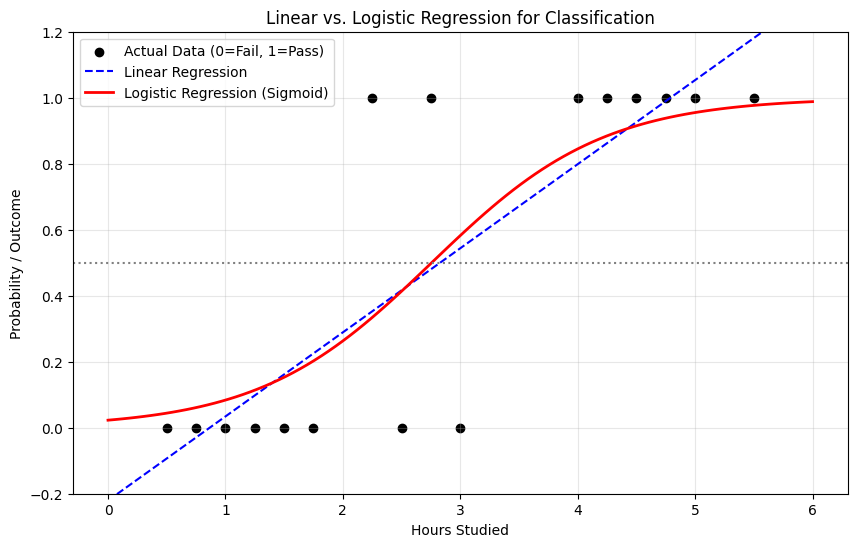

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

# 1. Create Synthetic Data
# Hours studied (x) vs Pass/Fail (y: 0 or 1)
x = np.array([0.5, 0.75, 1, 1.25, 1.5, 1.75, 2.25, 2.5, 2.75, 3, 4, 4.25, 4.5, 4.75, 5, 5.5]).reshape(-1, 1)
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# 2. Fit Linear Regression
lin_model = LinearRegression()
lin_model.fit(x, y)

# 3. Fit Logistic Regression
log_model = LogisticRegression()
log_model.fit(x, y)

# 4. Generate points for smooth plotting
x_range = np.linspace(0, 6, 100).reshape(-1, 1)
lin_pred = lin_model.predict(x_range)
log_prob = log_model.predict_proba(x_range)[:, 1] # Get probability of class 1

# 5. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label='Actual Data (0=Fail, 1=Pass)')

# Plot Linear Regression Line
plt.plot(x_range, lin_pred, color='blue', linestyle='--', label='Linear Regression')

# Plot Logistic Regression S-Curve
plt.plot(x_range, log_prob, color='red', linewidth=2, label='Logistic Regression (Sigmoid)')

# Add formatting
plt.axhline(0.5, color='gray', linestyle='dotted') # Decision Boundary
plt.ylim(-0.2, 1.2)
plt.xlabel('Hours Studied')
plt.ylabel('Probability / Outcome')
plt.title('Linear vs. Logistic Regression for Classification')
plt.legend()
plt.grid(alpha=0.3)
plt.show()